The mouse brain Visium data: [gene expression data and BAM files](https://www.10xgenomics.com/datasets/mouse-brain-serial-section-1-sagittal-posterior-1-standard-1-1-0).

The loom files of unspliced and spliced counts was processed from the BAM files by [Velocyto](https://github.com/velocyto-team/velocyto.py).

In [1]:
import pandas as pd
import numpy as np
import scanpy as sc
import os
import seaborn as sns
import matplotlib.pyplot as plt
import STAVelo as stv
stv.settings.verbosity = 3
stv.settings.presenter_view = True
stv.set_figure_params("scvelo")
import warnings
warnings.filterwarnings("ignore")

# Read data

In [2]:
label_df=pd.read_csv("../data/T2_Mouse_Brain_Visium_Sagittal_Posterior/adata_obs_annotation.csv", index_col=0)
label_df.index = label_df.index.str.replace("-1", "", regex=False)
label_df['in_tissue'] = label_df['in_tissue'].astype(int)
label_df['array_row'] = label_df['array_row'].astype(int)
label_df['array_col'] = label_df['array_col'].astype(int)
label_df['expression_louvain_label'] = label_df['expression_louvain_label'].astype(str)
label_df['louvain'] = label_df['louvain'].astype(str)

In [3]:
adata=sc.read_loom("../data/T2_Mouse_Brain_Visium_Sagittal_Posterior/possorted_genome_bam_D592L.loom")
adata.obs.index = adata.obs.index.str.replace("possorted_genome_bam_D592L:", "", regex=False)
label_df=label_df[label_df.index.isin(adata.obs.index)]
adata=adata[label_df.index]
adata.obs.loc[label_df.index, label_df.columns]=label_df

In [4]:
adata_raw=sc.read_visium("../data/T2_Mouse_Brain_Visium_Sagittal_Posterior/", count_file="filtered_feature_bc_matrix.h5")
adata_raw.obs.index = adata_raw.obs.index.str.replace("-1", "", regex=False)
adata_raw.obsm['spatial'][:,1] = adata_raw.obsm['spatial'][:,1]*(-1)
adata_raw=adata_raw[adata.obs.index]
adata.uns['spatial']=adata_raw.uns['spatial']
adata.obsm['spatial']=adata_raw.obsm['spatial']
adata.obsm['spatial']=adata.obsm['spatial'].astype('float64')

In [5]:
adata.obs.loc[:,["louvain","annotation"]]=label_df.loc[adata.obs_names,["louvain","annotation"]]
categories_order=['Cerebellum', 'Cerebral cortex', 'Fiber tracts', 'Hindbrain', 'Hippocampus', 'Hypothalamus', 'Midbrain', 'Thalamus']
adata.obs['annotation'] = adata.obs['annotation'].astype(pd.CategoricalDtype(categories=categories_order, ordered=False))
adata.uns["annotation_colors"]=['#17becf','#018435','#97d6f9','#d62728','#ad40ff','#ffc082','#fe7f0e','#8c564b']

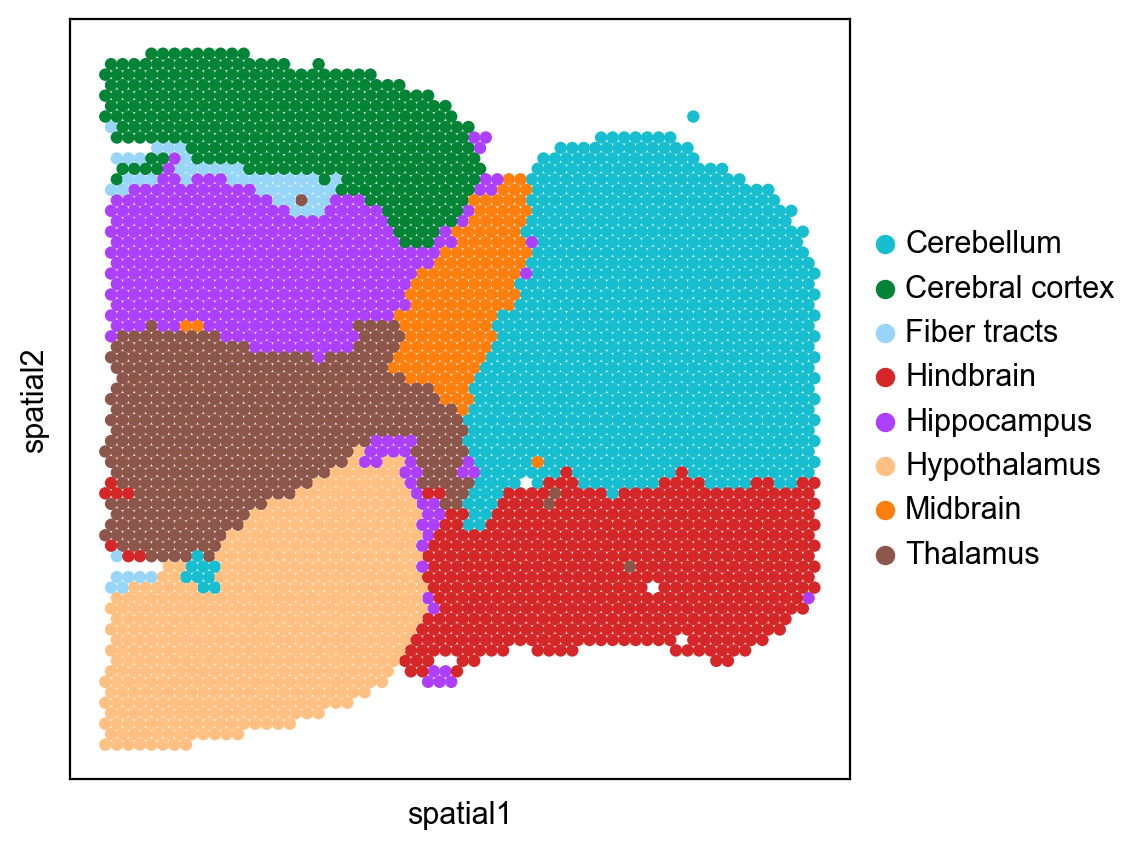

In [6]:
plt.rcParams["figure.figsize"] = (5, 5)
sc.pl.embedding(adata, basis="spatial", color="annotation", title="", s=80)

# Run model

In [7]:
stv.show_proportions(adata)
adata

Abundance of ['unspliced', 'spliced', 'ambiguous']: [0.83 0.12 0.05]


AnnData object with n_obs × n_vars = 3343 × 57010
    obs: 'in_tissue', 'array_row', 'array_col', 'expression_louvain_label', 'louvain', 'annotation'
    var: 'Accession', 'Chromosome', 'End', 'Start', 'Strand'
    uns: 'spatial', 'annotation_colors'
    obsm: 'spatial'
    layers: 'matrix', 'ambiguous', 'spliced', 'unspliced'

In [8]:
stv.filter_and_normalize(adata, min_shared_counts=2, n_top_genes=1000)
stv.moments(adata, n_pcs=30, n_neighbors=30)

Filtered out 54357 genes that are detected 2 counts (shared).
Normalized count data: X, spliced, unspliced.
Extracted 1000 highly variable genes.
Logarithmized X.
computing neighbors
    finished (0:00:10) --> added 
    'distances' and 'connectivities', weighted adjacency matrices (adata.obsp)
computing moments based on connectivities
    finished (0:00:00) --> added 
    'Ms' and 'Mu', moments of un/spliced abundances (adata.layers)


In [9]:
stv.Cal_Spatial_Net(adata, rad_cutoff=150)

------Calculating spatial graph...
The graph contains 19490 edges, 3343 cells.
5.8301 neighbors per cell on average.


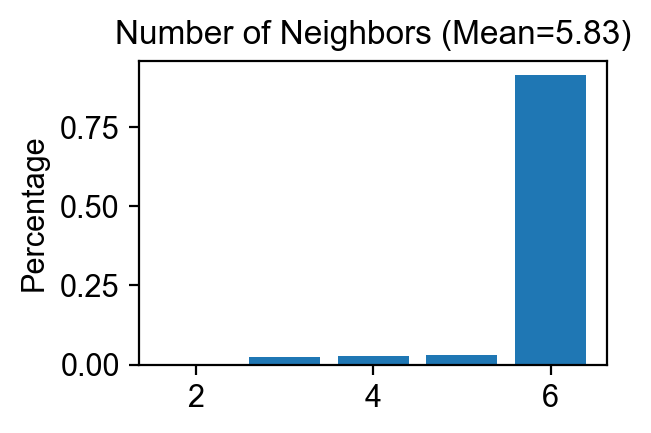

In [10]:
stv.Stats_Spatial_Net(adata)

In [11]:
adata = stv.train_STAVelo(adata, loss_type="cosine", w1 = 1, w2 = 1, random_seed=1234, device = 'cuda:0')

Size of Input:  (3342, 1000)


100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 1000/1000 [00:06<00:00, 153.56it/s]


In [12]:
stv.velocity_graph(adata, n_neighbors=2000, n_jobs=16)

computing velocity graph (using 16/384 cores)


  0%|          | 0/3342 [00:00<?, ?cells/s]

    finished (0:00:10) --> added 
    'velocity_graph', sparse matrix with cosine correlations (adata.uns)


# Velocity visualization

In [13]:
#adata=sc.read("./result/adata.h5ad")

Renamed 'spatial' to convention 'X_spatial' (adata.obsm).
computing velocity embedding
    finished (0:00:00) --> added
    'velocity_spatial', embedded velocity vectors (adata.obsm)


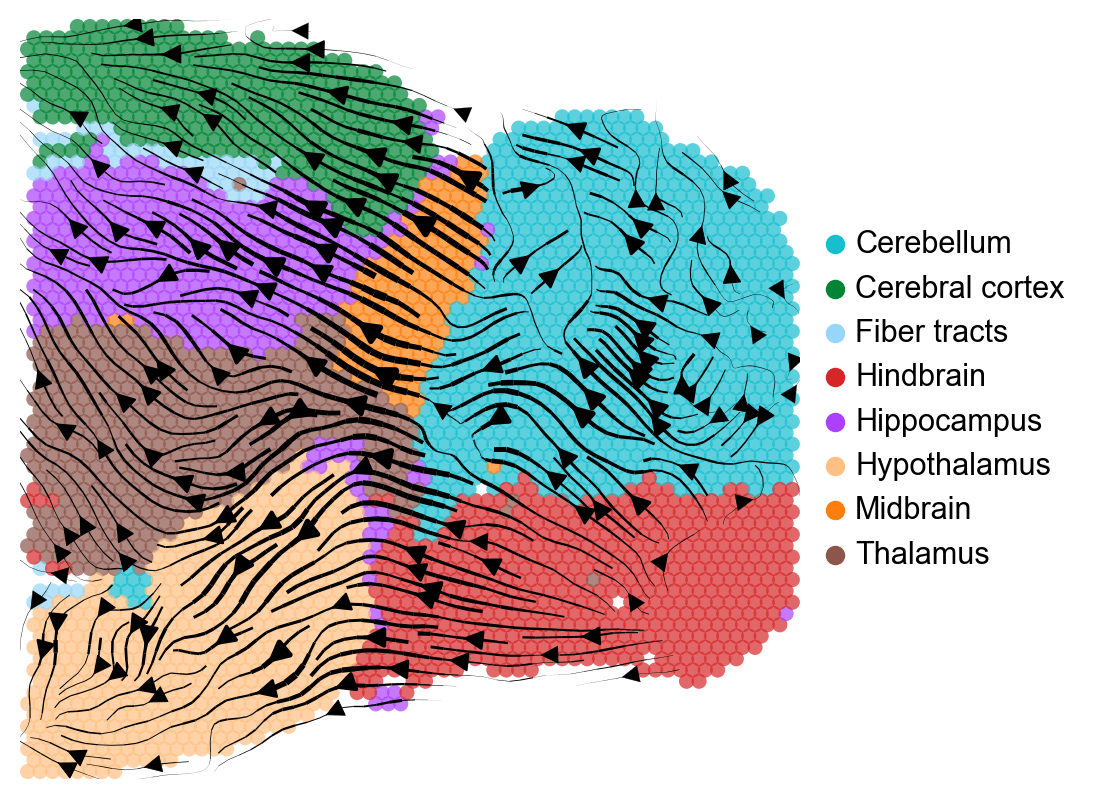

In [14]:
plt.rcParams["figure.figsize"] = (5, 5)
stv.velocity_embedding_stream(adata, basis='spatial', color="annotation", title="", legend_loc="right", alpha=0.7, size=120, 
                              linewidth=1.5, arrow_size=1.5)

In [15]:
#if not os.path.exists("./result"):
#    os.makedirs("./result")
#adata.write("./result/adata.h5ad")